In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd() / "src")) 

import numpy as np  # arrays, linear algebra, numerical computing
from qutip import Bloch  # visualization of single-qubit states (Bloch sphere)  
import matplotlib.pyplot as plt  # plotting and visualization

from quantum_error_corrections import (
    I, X, Y, Z, H, P0, P1, I8, X1, X2, X3, Z1, Z2, Z3, E1_rho,  bit_flip_kraus_nqubits, 
    U_N_qubits, U_one_gate, U_two_gates, controlled_gate, rotation_gate,
    rho, evolve, recovery_bit_flip, depolarizing_kraus_nqubits, correct_phase_flip,  
    recovery_phase_flip, initial_state, apply_hadamards, normalize_state, 
    projectors, born_rule_probs, sample_from_probs, single_qubit_channel_n_register, 
    measure_pure_state, measurement_density_matrix, 
    measure_probs_first_n, sample_measurements_input, sample_probs, rotation_channel, 
    bit_flip_kraus, phase_flip_kraus, amplitude_damping_kraus, encode_3_qubit_phase_flip_code, 
    phase_damping_kraus, depolarizing_kraus, pauli_kraus_channel, bit_flip_channel_3qubits, syndrome_measurement_bit_flip,  
    apply_channel, apply_kraus, E1_rho, bloch_visualization, correct_bit_flip, syndrome_measurement_phase_flip, 
    dm, random_pure_state, ket0, ket1, ket_plus, bloch_vector, encode_3_qubit_bit_flip_code, ket_minus, apply_kraus_sparse, 
    buildSparseGateSingle, buildSparseCNOT, dm_sparse, ket0_sparse, bit_flip_kraus_nqubits_sparse, doMeasurement
)

### Bloch Sphere Visualization of Quantum Noise Channels

Write a function that takes as an input (1) a density matrix of a single qubit and (2) the list of Kraus operators defining the channels and returns the density matrix after the channel has been applied.

Test your functions by applying, e.g., the to the states $|0\rangle$ and $|+\rangle$.
Amplitude Damping channels affect the qubit states |0⟩ and |+⟩. Green arrows represent the original states, and red arrows represent the states after the noise channel.

psi:
 [1.+0.j 0.+0.j]

rho_in:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Amplitude damping Kraus operators:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.        +0.j, 0.54772256+0.j],
       [0.        +0.j, 0.        +0.j]])]

Density matrix after amplitude damping:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

initial Bloch vector:
 [0. 0. 1.]
Bloch vector after amplitude damping:
 [0. 0. 1.]


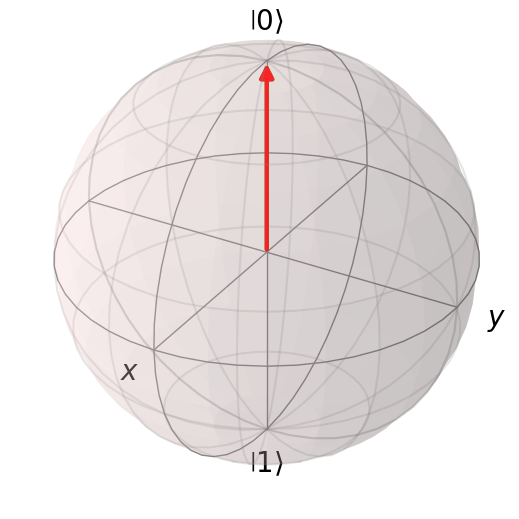

In [2]:
gamma = 0.3   
psi = ket0() 
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
kraus_amp = amplitude_damping_kraus(gamma)
print()
print("Amplitude damping Kraus operators:\n", kraus_amp)
rho_amp = apply_kraus(rho_in, kraus_amp)
print()
print("Density matrix after amplitude damping:\n", rho_amp)
print()
v_initial = bloch_vector(rho_in)
v_amp = bloch_vector(rho_amp)
print("initial Bloch vector:\n", v_initial)
print("Bloch vector after amplitude damping:\n", v_amp)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_amp)        
b.title = "Amplitude Damping Channel effect on |1>"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Amplitude_damping_kraus:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.        +0.j, 0.54772256+0.j],
       [0.        +0.j, 0.        +0.j]])]
Density matrix after amplitude damping:
 [[0.3+0.j 0. +0.j]
 [0. +0.j 0.7+0.j]]
Initial Bloch vector:
 [ 0.  0. -1.]
After damping Bloch vector :
 [ 0.   0.  -0.4]


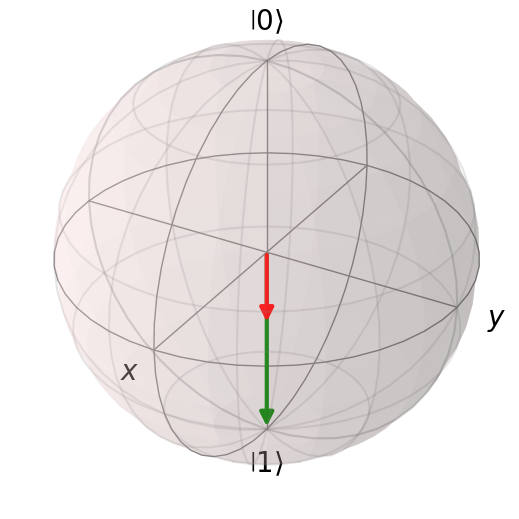

In [3]:
gamma = 0.3
psi = ket1()
rho_in = np.outer(psi, psi.conj())

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

kraus_amp = amplitude_damping_kraus(gamma)

print()
print("Amplitude_damping_kraus:\n", kraus_amp)

rho_out = apply_kraus(rho_in, kraus_amp)

print("Density matrix after amplitude damping:\n", rho_out)

v_initial = bloch_vector(rho_in)
v_final = bloch_vector(rho_out)

print("Initial Bloch vector:\n", v_initial)
print("After damping Bloch vector :\n", v_final)

b = Bloch()
b.vector_color = ['green','red']

b.add_vectors(v_initial)
b.add_vectors(v_final)

b.title = "Amplitude Damping Channel"

b.show()

psi:
 [0.70710678+0.j 0.70710678+0.j]

rho_in:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

Amplitude damping Kraus operators:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.        +0.j, 0.54772256+0.j],
       [0.        +0.j, 0.        +0.j]])]

Density matrix after amplitude damping:
 [[0.65      +0.j 0.41833001+0.j]
 [0.41833001+0.j 0.35      +0.j]]

Initial Bloch vector:
 [1. 0. 0.]
Bloch vector after amplitude damping:
 [0.83666003 0.         0.3       ]


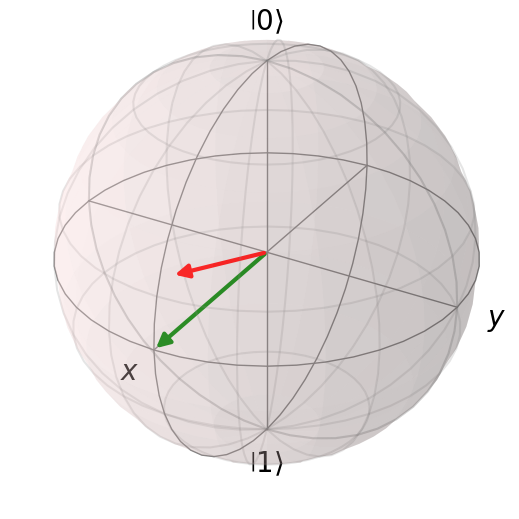

In [4]:
gamma = 0.3   
psi = ket_plus() 
rho_in = np.outer(psi, psi.conj())  

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

kraus_amp = amplitude_damping_kraus(gamma)
print()
print("Amplitude damping Kraus operators:\n", kraus_amp)

rho_amp = apply_kraus(rho_in, kraus_amp)
print()
print("Density matrix after amplitude damping:\n", rho_amp)
print()

v_initial = bloch_vector(rho_in)
v_amp = bloch_vector(rho_amp)
print("Initial Bloch vector:\n", v_initial)
print("Bloch vector after amplitude damping:\n", v_amp)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_amp)        
b.title = "Amplitude Damping Channel Effect on |1>"
b.show()

psi:
 [ 0.70710678+0.j -0.70710678+0.j]

rho_in:
 [[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]

Amplitude_damping_kraus:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.        +0.j, 0.54772256+0.j],
       [0.        +0.j, 0.        +0.j]])]
Density matrix after amplitude damping:
 [[ 0.65      +0.j -0.41833001+0.j]
 [-0.41833001+0.j  0.35      +0.j]]
Initial Bloch vector:
 [-1.  0.  0.]
After damping:
 [-0.83666003  0.          0.3       ]


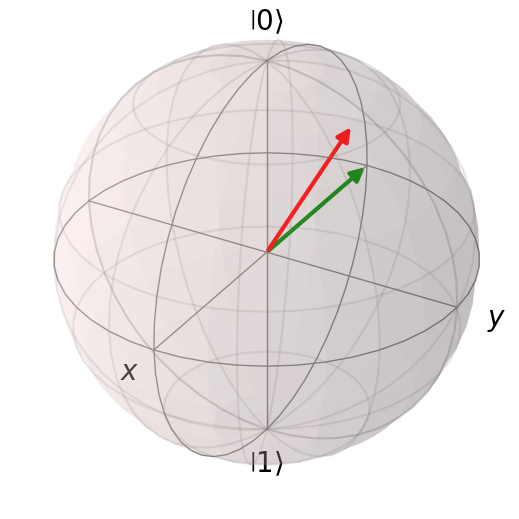

In [5]:
gamma = 0.3
psi = ket_minus()
rho_in = dm(psi)

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

kraus_amp = amplitude_damping_kraus(gamma)
print()
print("Amplitude_damping_kraus:\n", kraus_amp)

rho_out = apply_kraus(rho_in, kraus_amp)
print("Density matrix after amplitude damping:\n", rho_out)
v_initial = bloch_vector(rho_in)
v_final = bloch_vector(rho_out)

print("Initial Bloch vector:\n", v_initial)
print("After damping:\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Amplitude Damping Channel"
b.show()

### Fidelity of a Qubit under Amplitude Damping

**amplitude damping channel** models energy loss from a qubit, such as spontaneous decay from the excited state \(|1\rangle\) to the ground state \(|0\rangle\).  

- For the **\(|0\rangle\) state**, no decay occurs, so the fidelity remains 1.  
- For the **\(|1\rangle\) state**, amplitude damping reduces the excited-state population, lowering the fidelity as the damping probability increases.  

The **fidelity** measures how close the final damped state is to the original state.  

This means the **fidelity decreases with increasing damping probability**, and a plot of fidelity vs. damping probability illustrates this trend.

gamma = 0.1
density matrix rho_out =
 [[0.55      +0.j 0.47434165+0.j]
 [0.47434165+0.j 0.45      +0.j]]


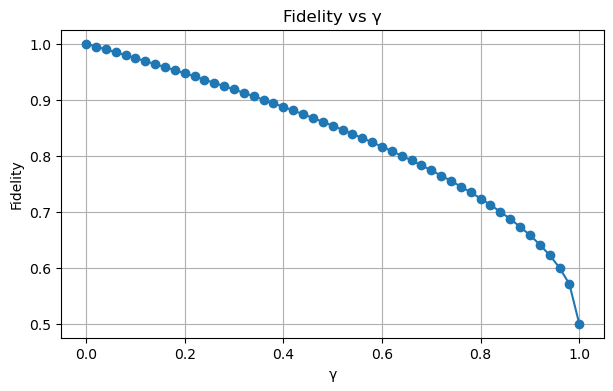

In [6]:
#Basic helpers
def rho_from_state(psi):
    return np.outer(psi, np.conjugate(psi))

def fidelity_pure_vs_rho(psi, rho):
    return float(np.real(np.vdot(psi, rho @ psi)))

psi = ket_plus()              
rho = rho_from_state(psi)     

gammas= np.linspace(0, 1, 51)
F = []
for g in gammas:
    kraus_ops = amplitude_damping_kraus(g)
    rho_out = apply_kraus(rho, kraus_ops)
    F.append(fidelity_pure_vs_rho(psi, rho_out))

# Print example
gamma = 0.1
rho_test = apply_kraus(rho, amplitude_damping_kraus(gamma))
print("gamma =", gamma)
print("density matrix rho_out =\n", rho_test)

# Plot fidelity
plt.figure(figsize=(7,4))
plt.plot(gammas, F, marker="o")
plt.xlabel("γ")
plt.ylabel("Fidelity")
plt.title("Fidelity vs γ")
plt.grid(True)
plt.show()

gamma =
 0.4
density matrix rho_out =
 [[ 0.7       +0.j -0.38729833+0.j]
 [-0.38729833+0.j  0.3       +0.j]]


/home/f73aeabd-6de4-471d-92a9-1ba552ae6153/.local/lib/python3.12/site-packages/quantum_error_corrections/operator.py:449: RuntimeWarning: invalid value encountered in sqrt
  [0, np.sqrt(1 - gamma)]], dtype=complex)


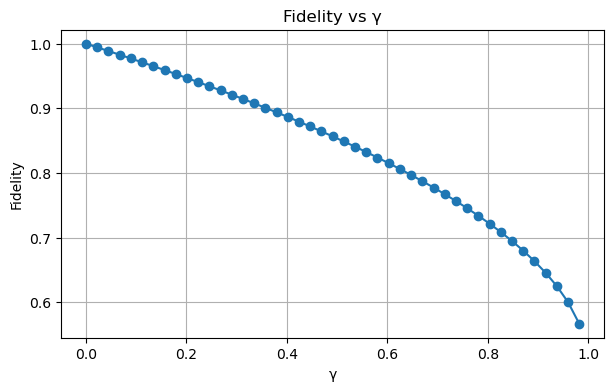

In [7]:
psi = ket_minus()             
psi = np.array(psi, dtype=complex)
rho = rho_from_state(psi)     

gammas= np.linspace(0, 5, 225)
F = []

for g in gammas:
    kraus_ops = amplitude_damping_kraus(g)
    rho_out = apply_kraus(rho, kraus_ops)
    F.append(fidelity_pure_vs_rho(psi, rho_out))

# Print example
gamma = 0.4
rho_test = apply_kraus(rho, amplitude_damping_kraus(gamma))
print("gamma =\n", gamma)
print("density matrix rho_out =\n", rho_test)

# Plot fidelity
plt.figure(figsize=(7,4))
plt.plot(gammas, F, marker="o")
plt.xlabel("γ")
plt.ylabel("Fidelity")
plt.title("Fidelity vs γ")
plt.grid(True)
plt.show()

gamma =
 0.9
density matrix rho_out =
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


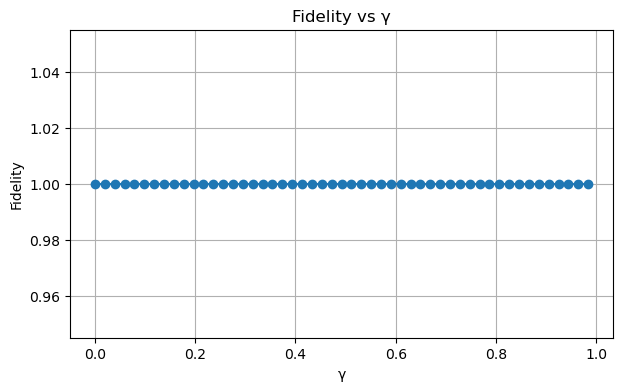

In [8]:
psi = ket0()             
psi = np.array(psi, dtype=complex)
rho = rho_from_state(psi)     

gammas = np.linspace(0, 6, 306)   
F = []

for g in gammas:
    kraus_ops = amplitude_damping_kraus(g)
    rho_out = apply_kraus(rho, kraus_ops)
    F.append(fidelity_pure_vs_rho(psi, rho_out))

# Print example
gamma= 0.9
rho_test = apply_kraus(rho, amplitude_damping_kraus(gamma))

print("gamma =\n", gamma)
print("density matrix rho_out =\n", rho_test)

# Plot fidelity
plt.figure(figsize=(7,4))
plt.plot(gammas, F, marker="o")   
plt.xlabel("γ")
plt.ylabel("Fidelity")
plt.title("Fidelity vs γ")
plt.grid(True)
plt.show()

gamma =
 0.9
density matrix rho_out =
 [[0.9+0.j 0. +0.j]
 [0. +0.j 0.1+0.j]]


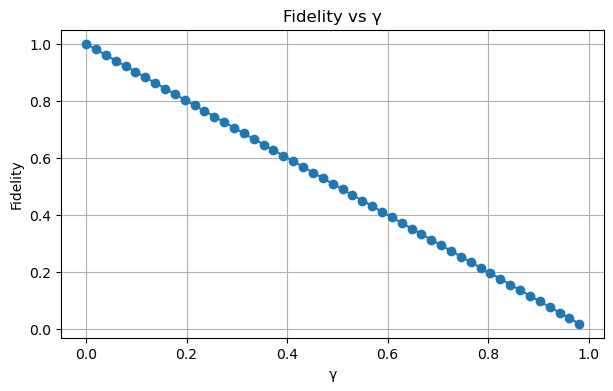

In [9]:
psi = ket1()             
psi = np.array(psi, dtype=complex)
rho = rho_from_state(psi)     

gammas = np.linspace(0, 20, 1020)   
F = []

for g in gammas:
    kraus_ops = amplitude_damping_kraus(g)
    rho_out = apply_kraus(rho, kraus_ops)
    F.append(fidelity_pure_vs_rho(psi, rho_out))

# Print example
gamma= 0.9
rho_test = apply_kraus(rho, amplitude_damping_kraus(gamma))

print("gamma =\n", gamma)
print("density matrix rho_out =\n", rho_test)

# Plot fidelity
plt.figure(figsize=(7,4))
plt.plot(gammas, F, marker="o")   
plt.xlabel("γ")
plt.ylabel("Fidelity")
plt.title("Fidelity vs γ")
plt.grid(True)
plt.show()